### Data Exploration Exercises

Class balance check
Prompt:
Check how many samples there are for each class in the Digits dataset. Plot a bar chart of counts. Are the classes balanced?

Compute the proportion of each class relative to the total number of samples

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits



In [2]:
digits = load_digits()

In [ ]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [4]:
labels, counts = np.unique(digits.target, return_counts=True)

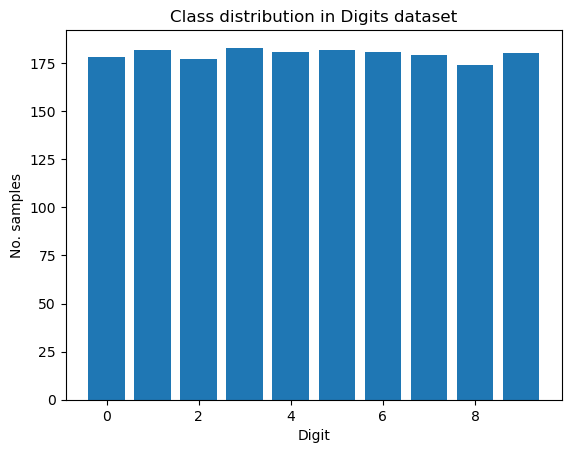

In [6]:
plt.bar(labels, counts)
plt.xlabel("Digit")
plt.ylabel("No. samples")
plt.title("Class distribution in Digits dataset")
plt.show()

In [7]:
proportions = counts/counts.sum()

In [9]:
for label, count, prop in zip(labels, counts, proportions):
    print(f" Class: {label}, {count} samples (prop: {prop:.2%})")

 Class: 0, 178 samples (prop: 9.91%)
 Class: 1, 182 samples (prop: 10.13%)
 Class: 2, 177 samples (prop: 9.85%)
 Class: 3, 183 samples (prop: 10.18%)
 Class: 4, 181 samples (prop: 10.07%)
 Class: 5, 182 samples (prop: 10.13%)
 Class: 6, 181 samples (prop: 10.07%)
 Class: 7, 179 samples (prop: 9.96%)
 Class: 8, 174 samples (prop: 9.68%)
 Class: 9, 180 samples (prop: 10.02%)


#### Feature range / scaling awareness
Prompt:
Compute the min, max, and mean of each feature in California Housing. Which features might need scaling before ML?

In [16]:
from sklearn.datasets import fetch_california_housing

cal = fetch_california_housing(as_frame=True)

summary = cal.frame.describe()

In [17]:
print(summary.T[['min', 'max', 'mean']])

                    min           max         mean
MedInc         0.499900     15.000100     3.870671
HouseAge       1.000000     52.000000    28.639486
AveRooms       0.846154    141.909091     5.429000
AveBedrms      0.333333     34.066667     1.096675
Population     3.000000  35682.000000  1425.476744
AveOccup       0.692308   1243.333333     3.070655
Latitude      32.540000     41.950000    35.631861
Longitude   -124.350000   -114.310000  -119.569704
MedHouseVal    0.149990      5.000010     2.068558


#### Feature-based slicing 
Use California Housing: select all rows where a feature meets a condition.
Example:
Select all houses where MedInc > 8 (high-income blocks).
Compute average MedHouseVal in this subset.

In [20]:
cal.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [21]:
# write code here
high_income = cal.frame[cal.frame['MedInc']>8]

In [22]:
high_income

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.52600
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.58500
131,11.6017,18.0,8.335052,1.082474,533.0,2.747423,37.84,-122.19,3.92600
134,8.2049,28.0,6.978947,0.968421,463.0,2.436842,37.83,-122.19,3.35200
135,8.4010,26.0,7.530806,1.056872,542.0,2.568720,37.83,-122.20,3.51200
...,...,...,...,...,...,...,...,...,...
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001
20427,8.6499,4.0,7.236059,1.032528,5495.0,2.553439,34.19,-118.80,5.00001
20428,8.7288,6.0,8.715842,1.102970,3385.0,3.351485,34.23,-118.83,4.25800
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69,5.00001


In [23]:
len(high_income)

690

In [27]:
print(high_income['MedHouseVal'].mean())

4.606393347826087


#### Distance / similarity between images
Prompt:
Pick two Olivetti Faces images. Compute the Euclidean distance between them. Which are “closer” or “farther” visually?


In [28]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

In [36]:
img1 = olivetti.images[0]

img2 = olivetti.images[100]


In [37]:
img1

array([[0.30991736, 0.3677686 , 0.41735536, ..., 0.37190083, 0.3305785 ,
        0.30578512],
       [0.3429752 , 0.40495867, 0.43801653, ..., 0.37190083, 0.338843  ,
        0.3140496 ],
       [0.3429752 , 0.41735536, 0.45041323, ..., 0.38016528, 0.338843  ,
        0.29752067],
       ...,
       [0.21487603, 0.20661157, 0.2231405 , ..., 0.15289256, 0.16528925,
        0.17355372],
       [0.20247933, 0.2107438 , 0.2107438 , ..., 0.14876033, 0.16115703,
        0.16528925],
       [0.20247933, 0.20661157, 0.20247933, ..., 0.15289256, 0.16115703,
        0.1570248 ]], shape=(64, 64), dtype=float32)

In [38]:
from numpy.linalg import norm

In [39]:
dist = norm(img1.ravel() - img2.ravel())

print(f" Distance: {dist:.2f}")

 Distance: 11.28


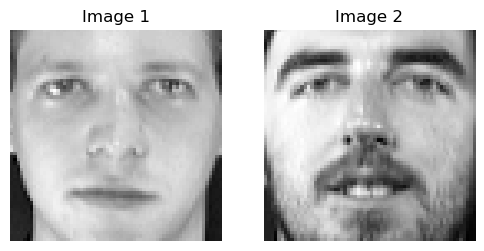

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img1, cmap='gray')
axes[0].set_title("Image 1")
axes[0].axis('off')
axes[1].imshow(img2, cmap='gray')
axes[1].set_title("Image 2")
axes[1].axis('off')
plt.show()

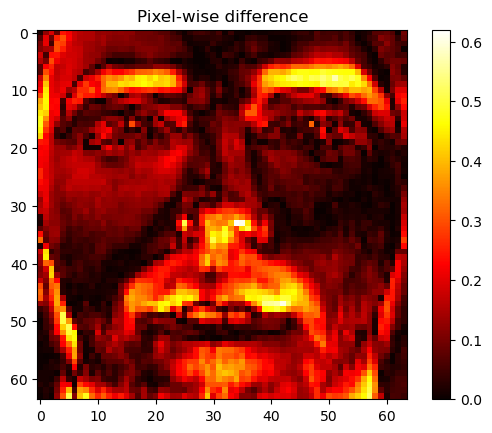

In [41]:
diff = np.abs(img1-img2)
plt.imshow(diff, cmap='hot')
plt.title("Pixel-wise difference")
plt.colorbar()
plt.show()

Image subset slicing by metadata
Use Olivetti Faces: select all images of a specific person.

Plot first 4 images of that person

In [51]:
person_id = 0

person_images = olivetti.images[olivetti.target == person_id]

print(f"Numbe of images per person: {person_id}: ", person_images.shape[0])

Numbe of images per person: 0:  10


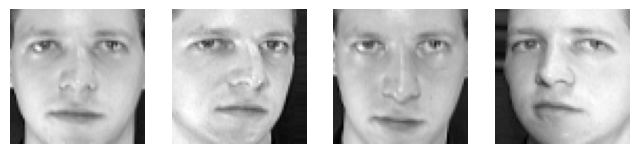

In [52]:
fig, axes = plt.subplots(1, 4 , figsize=(8,2))
for i, ax in enumerate(axes):
    ax.imshow(person_images[i], cmap='gray')
    ax.axis('off')
plt.show()

#### Reshaping image data
Prompt:
Flatten the first Olivetti Faces image into a 1D array. Then reshape it back to the original image shape for plotting.

Plot original and reshaped image to show they are the same


In [53]:
img = olivetti.images[0]

flattened = img.ravel()

print(img.shape, flattened.shape)

(64, 64) (4096,)


In [54]:
reshaped = flattened.reshape(img.shape)

In [55]:
print(reshaped.shape)

(64, 64)


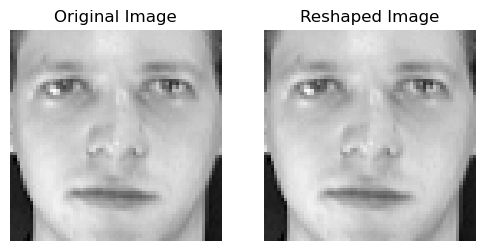

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')
axes[1].imshow(reshaped, cmap='gray')
axes[1].set_title("Reshaped Image")
axes[1].axis('off')
plt.show()

#### BONUS: Train/Test Split and Stratification
Prompt:
Explore how the class distribution changes depending on how you split the data. Use the Digits dataset.
Split the dataset into train (80%) and test (20%) without stratification.
Count the number of samples per class in each split. Are the classes balanced?
Repeat the split with stratification using the target. Compare the class counts.

In [8]:
# write code here
